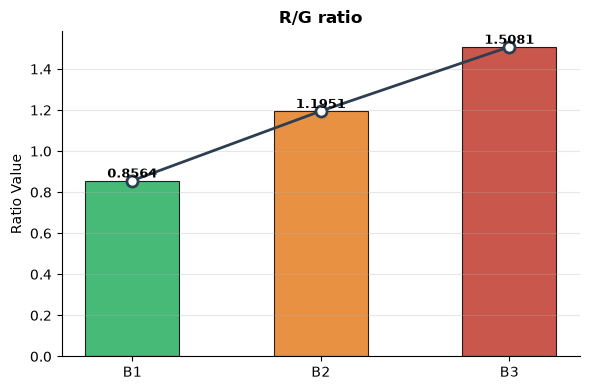

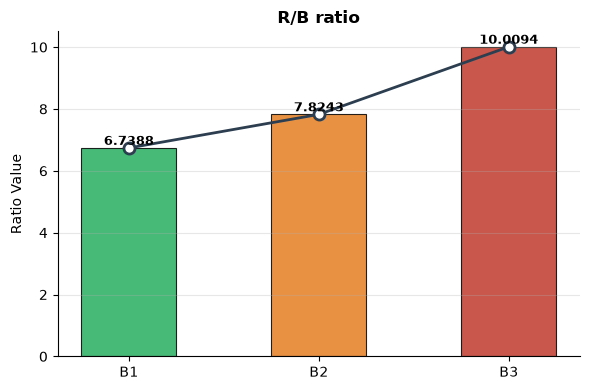

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import color

# ============================================================
# CONFIGURATION — JUJUBA
# ============================================================

jujuba = {
    "B1": {
        "files": [
            r"Data\Jujube\Sample_Images\B1_S1.jpeg",
            r"Data\Jujube\Sample_Images\B1_S2.jpeg",
        ],
        "circles": [(1600,2456,116),(1620,2420,116)],
        "color": "#27ae60",
        "label": "B1",
    },
    "B2": {
        "files": [
            r"Data\Jujube\Sample_Images\B2_S1.jpeg",
            r"Data\Jujube\Sample_Images\B2_S2.jpeg",
        ],
        "circles": [(1573,2296,116),(1653,2333,116)],
        "color": "#e67e22",
        "label": "B2",
    },
    "B3": {
        "files": [
            r"Data\Jujube\Sample_Images\B3_S1.jpeg",
            r"Data\Jujube\Sample_Images\B3_S2.jpeg",
        ],
        "circles": [(1696,2446,116),(1673,2510,116)],
        "color": "#c0392b",
        "label": "B3",
    },
}

# ============================================================
# FEATURE EXTRACTION
# ============================================================

summary = {}

for bid, data in jujuba.items():
   
    L_list, a_list, b_list = [], [], []
    rg_list, rb_list, nd_list = [], [], []

    for idx, (file, circle) in enumerate(zip(data["files"], data["circles"])):

        img = cv2.imread(file)
        if img is None:
            print(f"[ERROR] {file}")
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_norm = img_rgb.astype(np.float32) / 255.0
        
        x, y, r = circle
        mask = np.zeros(img.shape[:2], dtype=np.uint8)
        cv2.circle(mask, (x, y), r, 255, -1)


        pix_rgb = img_rgb[mask == 255].astype(np.float32)
        R = np.mean(pix_rgb[:,0])
        G = np.mean(pix_rgb[:,1])
        B = np.mean(pix_rgb[:,2])

        rg_list.append(R/G if G else 0)
        rb_list.append(R/B if B else 0)
        nd_list.append((R-G)/(R+G) if (R+G) else 0)       

    summary[bid] = {      
       
        "rg": np.array(rg_list),
        "rb": np.array(rb_list),
        "nd": np.array(nd_list),
    }

# ============================================================
# PLOTS
# ============================================================

ids = ["B1","B2","B3"]

bar_colors  = ['#27ae60', '#e67e22', '#c0392b']
trend_color = '#2c3e50'

x = np.array([1, 2, 3])
x_lbls = ['B1', 'B2', 'B3']

# ============================================================
#  R/G
# ============================================================

plt.figure(figsize=(6,4))
ax = plt.gca()

vals = [np.mean(summary[o]["rg"]) for o in ids]

bars = ax.bar(x, vals, color=bar_colors, width=0.5,
              alpha=0.85, edgecolor='black', linewidth=0.8)

ax.plot(x, vals, 'o-', color=trend_color,
        linewidth=2, markersize=8,
        markerfacecolor='white', markeredgewidth=2)

for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.01*max(vals),
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

ax.set_title("R/G ratio", fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(x_lbls)
ax.set_ylabel("Ratio Value")
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('RG Ratio.png', dpi=600, bbox_inches='tight')

plt.show()

# ============================================================
#  R/B
# ============================================================

plt.figure(figsize=(6,4))
ax = plt.gca()

vals = [np.mean(summary[o]["rb"]) for o in ids]

bars = ax.bar(x, vals, color=bar_colors, width=0.5,
              alpha=0.85, edgecolor='black', linewidth=0.8)

ax.plot(x, vals, 'o-', color=trend_color,
        linewidth=2, markersize=8,
        markerfacecolor='white', markeredgewidth=2)

for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.01*max(vals),
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

ax.set_title("R/B ratio", fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(x_lbls)
ax.set_ylabel("Ratio Value")
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('RB Ratio.png', dpi=600, bbox_inches='tight')
plt.show()

